In [ ]:
# Célula 1: Instalar dependências
# Instala bibliotecas necessárias para o projeto
!pip install tensorflow numpy pillow matplotlib scikit-learn

In [ ]:
# Célula 2: Importar bibliotecas e limpar sessão
# Importa bibliotecas e limpa a sessão do Keras para evitar problemas de memória
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import tensorflow as tf

tf.keras.backend.clear_session()

In [ ]:
# Célula 3: Montar Google Drive e definir configurações
# Monta o Google Drive e define parâmetros do modelo
from google.colab import drive
drive.mount('/content/drive')

# Configurações
IMAGE_SIZE = (128, 128)  # Tamanho para redimensionar as imagens
BATCH_SIZE = 32          # Tamanho do lote
EPOCHS = 10              # Número de épocas

# Caminho para as imagens no Google Drive
image_folder = '/content/drive/MyDrive/FIAP/dataset/train/bicicleta'

# Verifica se o diretório existe
if not os.path.exists(image_folder):
    raise FileNotFoundError(f"O diretório {image_folder} não foi encontrado. Verifique o caminho.")

Mounted at /content/drive


In [ ]:
# Célula 4: Funções para carregar dados
# Define funções para carregar labels YOLO e o dataset
def load_yolo_label(label_path):
    """Carrega um arquivo de label no formato YOLO"""
    try:
        with open(label_path, 'r') as f:
            lines = f.readlines()
        # Pega apenas a classe (primeiro valor de cada linha)
        classes = [int(line.split()[0]) for line in lines if line.strip()]
        return classes
    except Exception as e:
        print(f"Erro ao carregar o arquivo de label {label_path}: {e}")
        return []

def load_dataset(folder_path):
    images = []
    labels = []

    # Lista todos os arquivos PNG no diretório
    for filename in os.listdir(folder_path):
        if filename.lower().endswith('.png'):
            # Caminhos dos arquivos
            img_path = os.path.join(folder_path, filename)
            label_path = os.path.join(folder_path, filename.replace('.png', '.txt'))

            # Carrega a imagem
            try:
                img = Image.open(img_path).convert('RGB')  # Força conversão para RGB
                img = img.resize(IMAGE_SIZE)
                img_array = np.array(img) / 255.0  # Normaliza para [0,1]

                # Verifica formato da imagem
                if img_array.shape != (IMAGE_SIZE[0], IMAGE_SIZE[1], 3):
                    print(f"Imagem {filename} ignorada: formato inválido {img_array.shape}")
                    continue

                # Carrega os labels
                if os.path.exists(label_path):
                    class_ids = load_yolo_label(label_path)
                    # Usa a classe mais frequente na imagem (para multi-objetos)
                    if class_ids:
                        most_common_class = max(set(class_ids), key=class_ids.count)
                        images.append(img_array)
                        labels.append(most_common_class)
                    else:
                        print(f"Arquivo de label {label_path} vazio ou inválido.")
                else:
                    print(f"Arquivo de label {label_path} não encontrado.")
            except Exception as e:
                print(f"Erro ao processar {filename}: {e}")

    return np.array(images), np.array(labels)

In [ ]:
# Célula 5: Carregar e processar dados
# Carrega o dataset e processa os labels
X, y = load_dataset(image_folder)

# Verifica se encontramos dados
if len(X) == 0 or len(y) == 0:
    raise ValueError("Nenhuma imagem ou label foi carregado. Verifique os caminhos e formatos.")

# Processa os labels
unique_classes = np.unique(y)
num_classes = len(unique_classes)
print(f"Classes encontradas: {unique_classes}")
print(f"Número de imagens: {len(X)}")

# Converte labels para one-hot encoding
y = to_categorical(y, num_classes=num_classes)

# Divide os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Classes encontradas: [0]
Número de imagens: 32


In [ ]:
# Célula 6: Definir e construir o modelo CNN
# Define a arquitetura do modelo CNN
def build_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# Cria o modelo
model = build_model(X_train[0].shape, num_classes)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Célula 7: Treinar o modelo
# Treina o modelo com os dados de treino e validação
history = model.fit(X_train, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_test, y_test),
                    verbose=1)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 921ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00 - v

In [ ]:
# Célula 8: Salvar o modelo
# Salva o modelo treinado no Google Drive
output_dir = '/content/drive/MyDrive/FIAP'
os.makedirs(output_dir, exist_ok=True)  # Cria o diretório se não existir
model.save(os.path.join(output_dir, 'bicicleta_classifier.h5'))
print(f"Modelo salvo em: {os.path.join(output_dir, 'bicicleta_classifier.h5')}")

Modelo salvo em: /content/drive/MyDrive/FIAP/bicicleta_classifier.h5


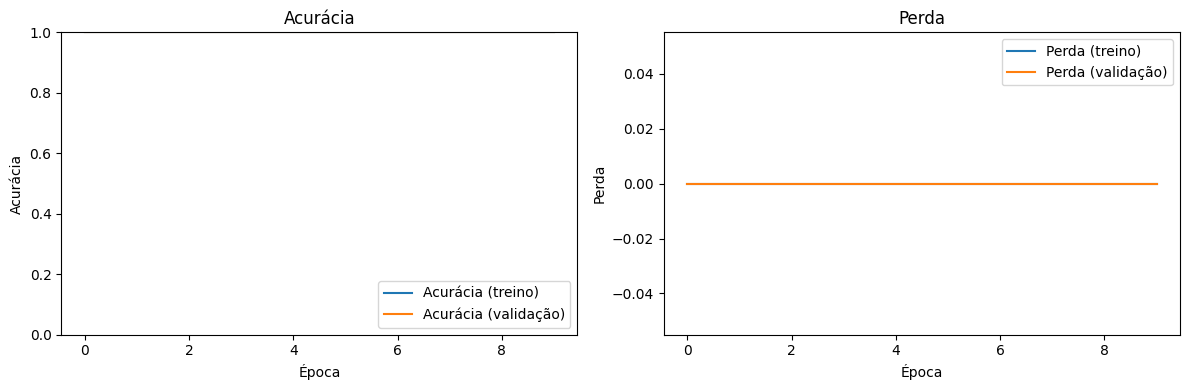

In [ ]:
# Célula 9: Plotar resultados
# Plota gráficos de acurácia e perda
plt.figure(figsize=(12, 4))

# Acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia (treino)')
plt.plot(history.history['val_accuracy'], label='Acurácia (validação)')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Acurácia')

# Perda
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Perda (treino)')
plt.plot(history.history['val_loss'], label='Perda (validação)')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend(loc='upper right')
plt.title('Perda')

plt.tight_layout()
plt.show()